# 03 - Search: minimax, alpha-beta, complexity

Choosing a move is a tree-search problem on the game tree:

$$ V(s) = \begin{cases}
\mathrm{eval}(s) & \text{if at depth limit} \\
\max_{a \in A(s)} V(s') & \text{if my turn} \\
\min_{a \in A(s)} V(s') & \text{if opponent's turn}
\end{cases} $$

Naive minimax visits $\Theta(b^d)$ nodes for branching factor $b$ and depth $d$. Chess has $b \approx 30$, so depth 6 is already a billion nodes.

Alpha-beta pruning skips subtrees that cannot change $V(s)$. With perfect move ordering this drops to $\Theta(b^{d/2})$. With random ordering it stays close to $b^d$.

We measure this empirically on five positions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import chess
import chess.svg
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, HTML, display

from chess_engine.evaluate import Evaluator
from chess_engine.search import negamax_alphabeta

## Test positions

Five positions of varying tactical density and game phase.

In [2]:
POSITIONS = [
    ('starting position',
     'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'),
    ('opening (after 1.e4 e5 2.Nf3 Nc6)',
     'r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3'),
    ('middlegame (Karpov-Kasparov 1985)',
     'r4rk1/1bq1bppp/p3pn2/1pp1n3/4P3/P1NPBN2/1PQ1BPPP/R4RK1 w - - 0 16'),
    ('late middlegame, both kings exposed',
     '2r3k1/5ppp/p2p4/1p1Pp3/4P3/1PP5/P4PPP/3R2K1 w - - 0 1'),
    ('king-and-pawn endgame',
     '8/8/8/4k3/4P3/4K3/8/8 w - - 0 1'),
]

svgs = ''.join(
    f'<div style="display:inline-block; text-align:center; padding:6px;">'
    f'<div style="font-size:11px;">{name}</div>'
    f'{chess.svg.board(chess.Board(fen), size=160)}</div>'
    for name, fen in POSITIONS
)
display(HTML(svgs))

## Nodes vs depth across three modes

Sweep $d \in \{1, 2, 3\}$ over each position in three modes:

- plain minimax (`prune=False, ordered=False`)
- alpha-beta with no ordering (`prune=True, ordered=False`)
- alpha-beta with MVV-LVA ordering (`prune=True, ordered=True`)

Plain minimax at depth 4 is too slow in pure Python (multi-second per call), so we cap it at 3 and let the alpha-beta variants go to 4.

In [3]:
evaluator = Evaluator.psqt_handcrafted()
MODES = [
    ('plain minimax',          {'prune': False, 'ordered': False}, [1, 2, 3]),
    ('alpha-beta',             {'prune': True,  'ordered': False}, [1, 2, 3, 4]),
    ('alpha-beta + MVV-LVA',   {'prune': True,  'ordered': True},  [1, 2, 3, 4]),
]

results = {name: {d: [] for d in depths} for name, _, depths in MODES}

for name, fen in POSITIONS:
    board = chess.Board(fen)
    for mode_name, kwargs, depths in MODES:
        for d in depths:
            score, nodes = negamax_alphabeta(board.copy(), d, evaluator, **kwargs)
            results[mode_name][d].append((nodes, score))
    print(f'  done: {name}')

  done: starting position
  done: opening (after 1.e4 e5 2.Nf3 Nc6)
  done: middlegame (Karpov-Kasparov 1985)
  done: late middlegame, both kings exposed
  done: king-and-pawn endgame


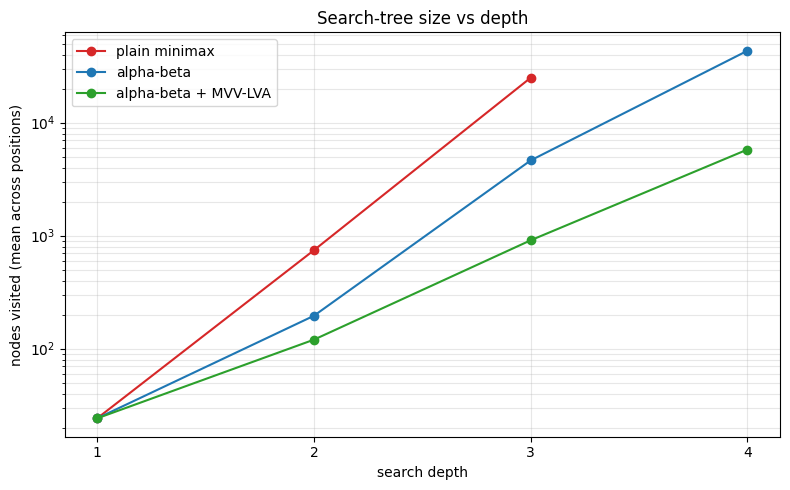

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'plain minimax': '#d62728', 'alpha-beta': '#1f77b4',
          'alpha-beta + MVV-LVA': '#2ca02c'}

for mode_name, _, depths in MODES:
    mean_nodes = [np.mean([n for n, _ in results[mode_name][d]]) for d in depths]
    ax.plot(depths, mean_nodes, marker='o', label=mode_name, color=colors[mode_name])

ax.set_yscale('log')
ax.set_xlabel('search depth')
ax.set_ylabel('nodes visited (mean across positions)')
ax.set_title('Search-tree size vs depth')
ax.set_xticks([1, 2, 3, 4])
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

Three approximately straight lines on log scale. Plain minimax is the steepest. Plain alpha-beta already prunes a lot, and MVV-LVA ordering on captures pulls the slope further down toward the $\Theta(b^{d/2})$ optimum.

## Empirical effective branching factor

Fit $\log N(d) \approx \log a + d \log b_\text{eff}$ by linear regression. The slope gives the average number of children explored per ply. With perfect ordering, alpha-beta should land near $\sqrt{b}$.

In [5]:
print(f"{'mode':25s}  {'b_eff':>7s}  {'theory':>20s}")
print('-' * 60)
for mode_name, _, depths in MODES:
    mean_nodes = [np.mean([n for n, _ in results[mode_name][d]]) for d in depths]
    slope, _intercept = np.polyfit(depths, np.log(mean_nodes), 1)
    b_eff = np.exp(slope)
    theory = ('~b (~30)' if 'plain' in mode_name
              else '~sqrt(b) (~5-6)' if 'MVV' in mode_name
              else 'between (b^0.5, b)')
    print(f'{mode_name:25s}  {b_eff:7.2f}  {theory:>20s}')

mode                         b_eff                theory
------------------------------------------------------------
plain minimax                32.13              ~b (~30)
alpha-beta                   12.98    between (b^0.5, b)
alpha-beta + MVV-LVA          6.33       ~sqrt(b) (~5-6)


## Pruning is correct

Alpha-beta is an optimisation, not an approximation. The score it returns is identical to plain minimax. We check that across every (position, depth) we ran.

In [6]:
all_match = True
for d in [1, 2, 3]:
    minimax_scores = [s for _, s in results['plain minimax'][d]]
    ab_scores      = [s for _, s in results['alpha-beta'][d]]
    abo_scores     = [s for _, s in results['alpha-beta + MVV-LVA'][d]]
    match_ab  = np.allclose(minimax_scores, ab_scores)
    match_abo = np.allclose(minimax_scores, abo_scores)
    all_match &= match_ab and match_abo
    print(f'depth {d}: minimax == alpha-beta:        {match_ab}')
    print(f'         minimax == alpha-beta+ordered: {match_abo}')

print()
print('all scores agree across modes:', all_match)
assert all_match, 'pruning changed the answer somewhere - bug!'

depth 1: minimax == alpha-beta:        True
         minimax == alpha-beta+ordered: True
depth 2: minimax == alpha-beta:        True
         minimax == alpha-beta+ordered: True
depth 3: minimax == alpha-beta:        True
         minimax == alpha-beta+ordered: True

all scores agree across modes: True


Every score matches. The orders-of-magnitude reduction in nodes buys nothing in correctness, which is the point. Pruning works because of the maximin structure: when the minimum we can guarantee already exceeds the opponent's max tolerance, exploring further can't change the answer.